In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.special import factorial

In [2]:
class StructureFactor1D:
    def __init__(self, nLattice,nPhononMax, q_list, mass=26161e3, omegaNaught=10e-6, latticeConst=2*np.pi/2.28, couplingConst=1):
        self.nLattice = nLattice # number of lattice
        self.nPhononMax = nPhononMax
        self.mass = mass # Silicon: 26161e3 keV
        self.omegaNaught = omegaNaught # Silicon: 10e-6 keV, correpsonds to maximum energy of 20 meV
        self.latticeConst = latticeConst # Silicon: 2*np.pi/2.28 keV^-1
        self.omegaList = 2*self.omegaNaught*np.sin(np.pi*np.arange(1, self.nLattice)/self.nLattice) # num of energy levels: nLattice-1
        self.couplingConst = couplingConst # A, default: 1
        self.volume = nLattice # propotional to nLattice
        self.q_list = q_list

    def getDebyeWallerConst(self):
        '''
        Get W(q) appearing in the debye waller factor
        '''
        return self.q_list**2 / (4*self.mass*self.nLattice) * np.sum(1/self.omegaList)

    def getJVector(self, nPhonon):
        '''
        Get all posible sets of j_nu given the total number of phonons. 
        nPhonon: int
        '''
        jVector = []
        for combo in itertools.product(range(nPhonon+1), repeat=self.nLattice-1): # num of energy levels: nLattice-1
            if sum(combo) == nPhonon:
                jVector.append(combo)
        return np.array(jVector)

    # for diag part
    def get_diag_sum_jVec_single_n(self, nPhonon): 
        '''
        Sum over all j vectors for one single n (the second summation in the equation)
        nPhonon: int
        '''
        jVector = self.getJVector(nPhonon)
        diag_sum_jVec_single_n = np.sum(1/np.prod(factorial(jVector)*(self.omegaList ** jVector), axis=1))
        # print("sum in diag",diag_sum_jVec_single_n)
        return diag_sum_jVec_single_n

    def get_diag_c_ll(self):
        '''
        find c_ll (without summing over l)
        '''
        factor = 2 * np.pi / self.volume * np.exp(- 2 * self.getDebyeWallerConst())
        # print("debyewaller exp",np.exp(- 2 * self.getDebyeWallerConst()))
        diag_sum_jVec_all_n_list = []
        nPhonon_list = np.arange(1, self.nPhononMax+1) 
        for n in nPhonon_list:
            diag_sum_jVec_all_n_list.append(self.get_diag_sum_jVec_single_n(n))
        diag_sum_jVec_all_n_list = np.array(diag_sum_jVec_all_n_list).reshape(-1, 1)
        return factor * np.sum((self.q_list**2/(2*self.mass*self.nLattice)) ** nPhonon_list.reshape(-1, 1) * diag_sum_jVec_all_n_list, axis=0)

    def get_structure_factor_diag_part(self):
        # print("diag S", self.get_diag_c_ll())
        return self.nLattice * self.get_diag_c_ll() * self.couplingConst**2


    # for off diag part
    def get_off_diag_sum_jVec_single_n_real_part(self, nPhonon, xi): 
        '''
        xi: integer, defined as l-l' 
        --------returns--------
        the summation of j_nu in Eqn. 61
        '''
        # dont forget to multiply 2 when calculating the structure factor
        jVector = self.getJVector(nPhonon)
        # print("xi",xi)
        cos_part = np.cos(xi * ((self.q_list[np.newaxis, :] * self.latticeConst) 
                                - 2 * np.pi * np.einsum('i,ji->j',np.arange(1, self.nLattice), jVector)[:, np.newaxis] / self.nLattice)) 
        prod_part = np.prod(1/(factorial(jVector)*(self.omegaList ** jVector)), axis=1)
        return np.sum(prod_part[:, np.newaxis]*cos_part,axis=0)



    def get_off_diag_c_ll_real_part(self, xi):
        factor = 2 * np.pi / self.volume * np.exp(- 2 * self.getDebyeWallerConst())
        off_diag_sum_jVec_all_n_real_part = []
        nPhonon_list = np.arange(1, self.nPhononMax+1) 
        for n in nPhonon_list:
            off_diag_sum_jVec_all_n_real_part.append(self.get_off_diag_sum_jVec_single_n_real_part(n, xi))
        off_diag_sum_jVec_all_n_real_part = np.array(off_diag_sum_jVec_all_n_real_part) # reshape(-1, self.q_list.shape[0])
        return factor * np.sum((self.q_list**2  / (2*self.mass*self.nLattice))** nPhonon_list.reshape(-1, 1) * off_diag_sum_jVec_all_n_real_part, axis=0)


    def get_structure_factor_off_diag_part(self):
        # TODO: rewrite this function
        summation = np.zeros(self.q_list.shape)
        for xi in range(1, self.nLattice):
            # print("xi, from last step", xi)
            summation += 2 * (self.nLattice-xi) * self.get_off_diag_c_ll_real_part(xi)
        return summation * self.couplingConst**2
    
    def get_off_diag_structure_factor_each_nu_const_DW(self, nu):
        debye_waller = np.exp(-self.q_list**2 / (4*self.mass*np.pi*self.omegaNaught))
        frac = (1 - np.cos(self.nLattice*(self.q_list*self.latticeConst- 2*np.pi*nu/self.nLattice))) / (1 - np.cos(self.q_list*self.latticeConst- 2*np.pi*nu/self.nLattice))
        return 2*np.pi*np.abs(self.couplingConst)**2/self.volume * debye_waller * frac * self.q_list**2/(2*self.mass*self.nLattice) / (2*self.omegaNaught*np.sin(np.pi*nu/self.nLattice))


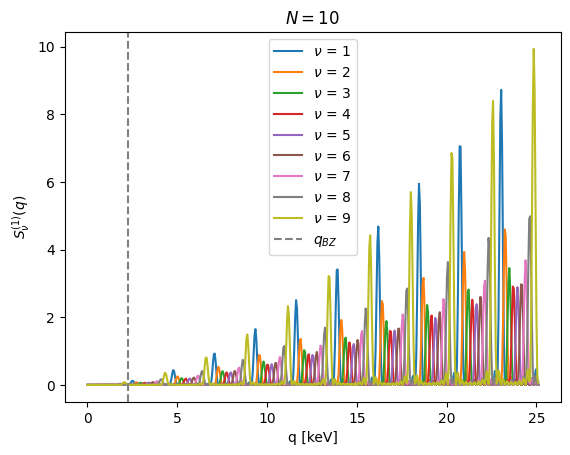

In [3]:
q_list = np.linspace(0,25.1,500)
nLattice = 10

test = StructureFactor1D(nLattice=nLattice,nPhononMax=1, q_list=q_list)

qbz = 2*np.pi/test.latticeConst
nu_string = r'$\nu$'

for i in range(1, nLattice):
    s_factor = test.get_off_diag_structure_factor_each_nu_const_DW(i)
    plt.plot(q_list,s_factor,label=f'{nu_string} = {i}')
plt.xlabel('q [keV]')
plt.ylabel(r'$S_\nu^{(1)}(q)$')
plt.axvline(qbz,color="gray",linestyle="--",label=r"$q_{BZ}$")
plt.title('$N=10$')
plt.legend()
plt.savefig("structure_factor_for_different_nu.png",dpi=200,bbox_inches='tight')

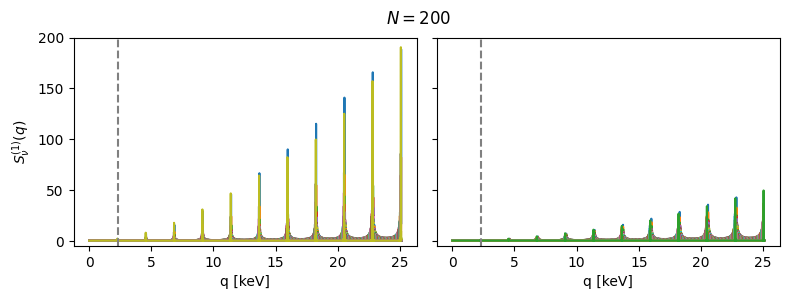

In [4]:
q_list = np.linspace(0,25.1, 5000)
nLattice = 200

test = StructureFactor1D(nLattice=nLattice,nPhononMax=1, q_list=q_list)

fig, axes = plt.subplots(1,2,figsize=(8,3.2),sharex=True, sharey=True)
for nu in range(1, nLattice):
    s_factor = test.get_off_diag_structure_factor_each_nu_const_DW(nu)
    axes[0].plot(q_list,s_factor,label=f'{nu_string} = {nu}')
    if 2*test.omegaNaught*np.sin(np.pi*nu/nLattice) > 1e-6:
        axes[1].plot(q_list,s_factor,label=f'{nu_string} = {nu}')
axes[0].set_xlabel('q [keV]')
axes[1].set_xlabel('q [keV]')
axes[0].set_ylabel(r'$S_\nu^{(1)}(q)$')
plt.ylim(-5,200)

axes[0].axvline(qbz,color="gray",linestyle="--",label=r"$q_{BZ}$")
axes[1].axvline(qbz,color="gray",linestyle="--",label=r"$q_{BZ}$")

# plt.title('Assuming the Debye-Waller factor is independent of $N$')
# plt.legend()
plt.suptitle(f"$N={nLattice}$",x=0.53,y=0.92)
plt.tight_layout()
# plt.savefig("structure_factor_for_different_nu_w_cut.png",dpi=200,bbox_inches='tight')

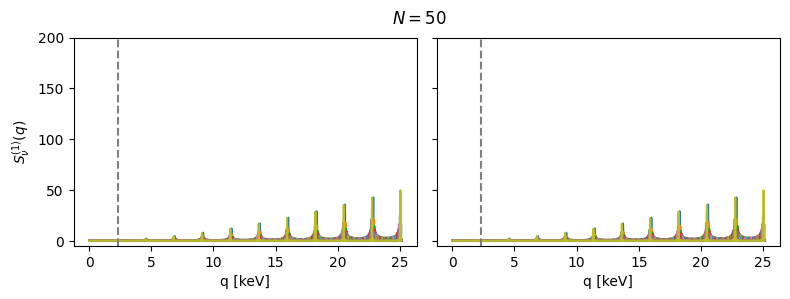

In [5]:
q_list = np.linspace(0,25.1, 5000)
nLattice = 50

test = StructureFactor1D(nLattice=nLattice,nPhononMax=1, q_list=q_list)

fig, axes = plt.subplots(1,2,figsize=(8,3.2),sharex=True, sharey=True)
for nu in range(1, nLattice):
    s_factor = test.get_off_diag_structure_factor_each_nu_const_DW(nu)
    axes[0].plot(q_list,s_factor,label=f'{nu_string} = {nu}')
    if 2*test.omegaNaught*np.sin(np.pi*nu/nLattice) > 1e-6:
        axes[1].plot(q_list,s_factor,label=f'{nu_string} = {nu}')
axes[0].set_xlabel('q [keV]')
axes[1].set_xlabel('q [keV]')
axes[0].set_ylabel(r'$S_\nu^{(1)}(q)$')
plt.ylim(-5,200)

axes[0].axvline(qbz,color="gray",linestyle="--",label=r"$q_{BZ}$")
axes[1].axvline(qbz,color="gray",linestyle="--",label=r"$q_{BZ}$")

# plt.title('Assuming the Debye-Waller factor is independent of $N$')
# plt.legend()
plt.suptitle(f"$N={nLattice}$",x=0.53,y=0.92)
plt.tight_layout()
# plt.savefig("structure_factor_for_different_nu_w_cut.png",dpi=200,bbox_inches='tight')

In [26]:
q_list = np.linspace(0.1,10, 2000)
nLattice = 600

test = StructureFactor1D(nLattice=nLattice,nPhononMax=1, q_list=q_list)

s_factor_list = []
nu_list = np.arange(1, nLattice//2+1)
omega_list = 2*test.omegaNaught*np.sin(np.pi*nu_list/nLattice)
if nLattice % 2 == 0: 
    for nu in nu_list[:-1]:
        if 2*test.omegaNaught*np.sin(np.pi*nu/nLattice) > 1e-6:
            s_factor = test.get_off_diag_structure_factor_each_nu_const_DW(nu) + test.get_off_diag_structure_factor_each_nu_const_DW(nLattice-nu)
        else:
            s_factor = np.zeros(q_list.shape)
        s_factor_list.append(s_factor)
    s_factor_list.append(test.get_off_diag_structure_factor_each_nu_const_DW(nu_list[-1]))
else: 
    for nu in nu_list:
        if 2*test.omegaNaught*np.sin(np.pi*nu/nLattice) > 1e-6:
            s_factor = test.get_off_diag_structure_factor_each_nu_const_DW(nu) + test.get_off_diag_structure_factor_each_nu_const_DW(nLattice-nu)
        else:
            s_factor = np.zeros(q_list.shape)
        s_factor_list.append(s_factor)
s_factor_list = np.array(s_factor_list)

In [27]:
s_factor_list.shape, omega_list.shape, q_list.shape

((300, 2000), (300,), (2000,))

In [28]:
# threshold = .8*1e-7
# new_omega_list = np.concatenate((omega_list, omega_list+threshold, omega_list-threshold))
# new_s_factor_list = np.concatenate((s_factor_list, np.zeros(s_factor_list.shape), np.zeros(s_factor_list.shape)), axis=0)

# new_s_factor_list = new_s_factor_list[np.argsort(new_omega_list)]
# new_omega_list = np.sort(new_omega_list)

# plt.pcolormesh(q_list, new_omega_list, np.log(new_s_factor_list+3e-07),shading='nearest', )
# plt.title('N=5, log scale')
# plt.colorbar(label=r'log $S(q, \omega)$')
# plt.ylabel(r"$\omega$ [keV]")
# plt.xscale('log')
# plt.xlabel("$q$ [keV]")
# plt.tight_layout()
# plt.savefig("2dlogscaleS", dpi=300, bbox_inches='tight', )


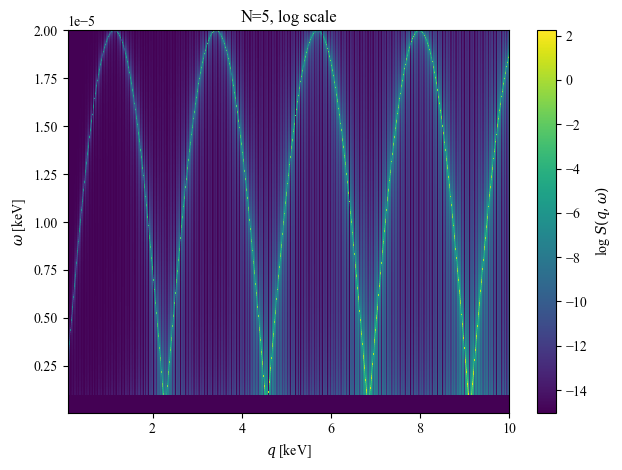

In [29]:
plt.pcolormesh(q_list, omega_list, np.log(s_factor_list+3e-07),shading='nearest', )
plt.title('N=5, log scale')
plt.colorbar(label=r'log $S(q, \omega)$')
plt.ylabel(r"$\omega$ [keV]")
plt.xlabel("$q$ [keV]")
plt.tight_layout()
plt.savefig("2dlogscaleS", dpi=300, bbox_inches='tight', )


In [10]:
arr = np.array([10, 20, 30, 40, 50])
arr[-1]


50

In [11]:
log_q_values = np.linspace(-1, np.log10(300), 8000) 
q_values = 10**log_q_values

test = StructureFactor1D(20, 1, np.linspace(0.1,3,10))
test.get_structure_factor_off_diag_part(), test.get_structure_factor_diag_part(),

(array([ 0.00025131, -0.00017008, -0.00246759, -0.00630427, -0.0105298 ,
        -0.01001067,  0.03011838,  0.09266719,  0.0024184 , -0.03813504]),
 array([0.0001193 , 0.00212607, 0.00660466, 0.01354446, 0.02292909,
        0.03473639, 0.04893848, 0.06550189, 0.08438763, 0.10555131]))

In [12]:
log_q_values = np.linspace(-1, np.log10(300), 8000) 
q_values = 10**log_q_values

N20n1 = StructureFactor1D(20, 1, q_values, couplingConst=5)
N20n1_diag_values = N20n1.get_structure_factor_diag_part()
N20n1_exact_values = N20n1.get_structure_factor_off_diag_part() + N20n1_diag_values

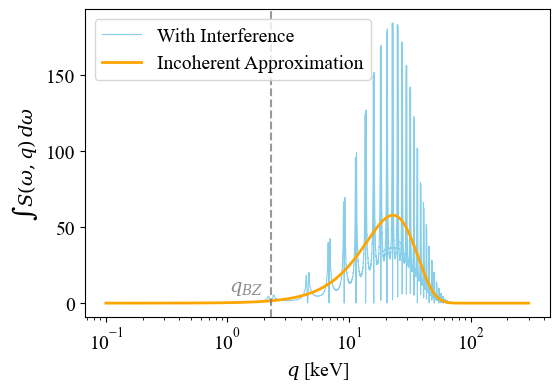

In [13]:
plt.rcParams['font.family'] = "Times New Roman"
plt.rcParams['mathtext.fontset'] = "dejavuserif"

plt.figure(figsize=(6,4))
plt.plot(q_values,N20n1_exact_values, linewidth=0.8,label="With Interference", color='skyblue')
plt.plot(q_values,N20n1_diag_values, linewidth=2, label="Incoherent Approximation", color='orange')
plt.xscale('log')
plt.ylabel(r"$\int S(\omega,q)\, d\omega$", size = 14)
plt.xlabel('$q$ [keV]', size = 14)
plt.tick_params(axis='both', labelsize=14)
plt.axvline(2*np.pi/N20n1.latticeConst, color='gray', linestyle='--',alpha=0.8)
plt.text(2*np.pi/N20n1.latticeConst*.45, 8, '$q_{BZ}$', color='gray', alpha=0.9, size=14)
# plt.yticks(np.arange(.5, .97, .05), [0.5, '',0.6, '', 0.7,'',0.8,'',0.9,''])


plt.legend(fontsize=14,loc='upper left')
# plt.savefig("20SiteLattice_1phonon.png",dpi=200, bbox_inches='tight' )
plt.show()

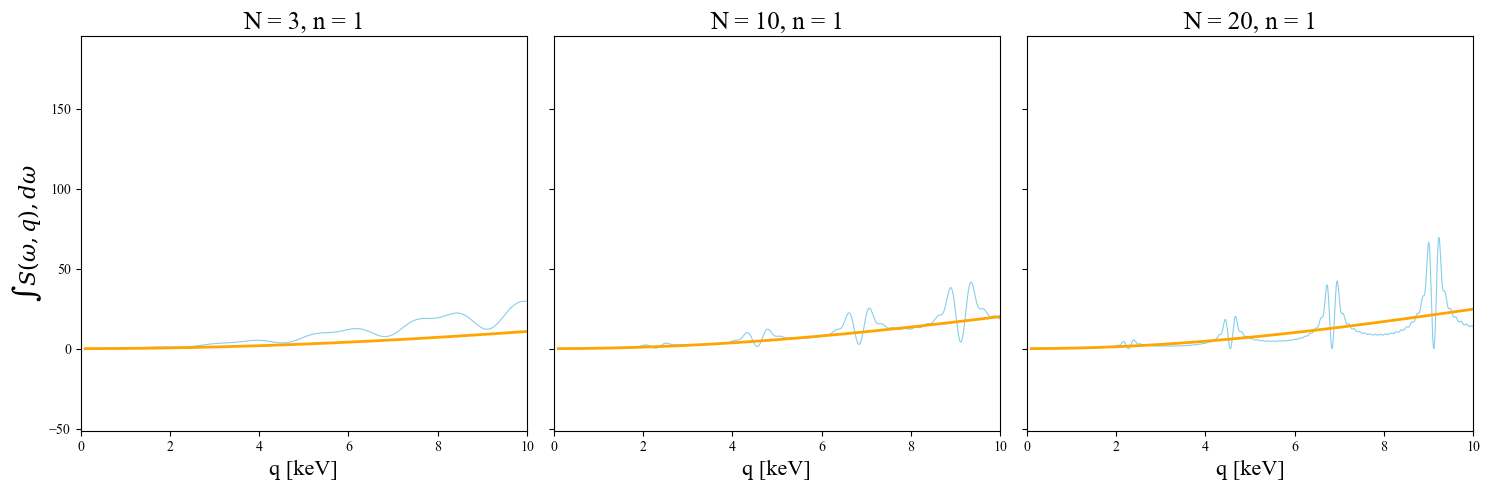

In [14]:
N_list = np.array([3,10,20])

fig, axes = plt.subplots(1,3,figsize=(15,5), sharex=True, sharey=True)

for i in range(3):
    structure = StructureFactor1D(N_list[i], 1, q_values, couplingConst=5)
    diag_values = structure.get_structure_factor_diag_part()
    exact_values = structure.get_structure_factor_off_diag_part() + N20n1_diag_values

    axes[i].plot(q_values, exact_values,linewidth=0.8,label="With Interference", color='skyblue')
    axes[i].plot(q_values, diag_values,linewidth=2, label="Incoherent Approximation", color='orange')
    axes[i].set_title(f"N = {N_list[i]}, n = 1", fontsize=18)
    axes[i].set_xlabel('q [keV]',size=16)
    axes[i].set_xlim(0, 10)
    # axes[i].set_xscale('log')
    if i == 0:
        axes[i].set_ylabel(r"$\int S(\omega,q), d\omega$", size=16)
plt.tight_layout()
# plt.savefig('different_sites_of_lattice',dpi=200, bbox_inches='tight')


The term 1/omega_nu could scale like N because the 2 pi nu /N gest closeser and closer to 0 as N gos inf, causing peaks

The structure factors actually depends on N even between the peaks (the peaks are very likely due to the omega_nu), and the valley is because I mannually removed the zero energy mode (divergence)
so TODO: figure out the N scaling for the peaks, and how are they 

Try qa half int multiples of 2pi (int mult of pi), and find the N scaling at that point 

ALSO debug this file :c
